# Xtream Gradient Boosting = **XGBoost**

In [ ]:
# modelo a parte do SKlearn
# cada arvore gerada, ele aprende com o resultado da anterior, gerando arvores com melhor desempenho
# E um dos modelos mais recentes. E uma melhoria do gradient boosting\
# penaliza previsoes incorretas

In [ ]:
## Vantagens
# Excelente desempenho em uma variedade de conjunto de dados
# Implementacao eficiente e escalavel
# Lida automaticamente com valores ausentes e variaveis categoricas
# Suporte para paralelismo e GPU

## Desvantagens
# Mais sensivel a overfitting em comparacao a outros modelos
# Requer ajuste fino de hiperparametros para obter melhor desempenho
# Pode ser mais lento para treino conjuntos com dados muito grandes

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

import xgboost as xgb

In [ ]:
# leitura de dados
df = pd.read_csv('diabetes.csv')
X = df.drop(columns=['Outcome'])
y = df['Outcome']
df.info()

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=101)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# Iniciando modelo
clf = xgb.XGBClassifier(seed=101) # equivale ao random state do sklearn
clf.fit(x_treino, y_treino)

pred = clf.predict(x_teste)
acc = accuracy_score(pred, y_teste)
print('Acuracia =', acc)

# acuracia inicial de 77%

Acuracia = 0.7748917748917749


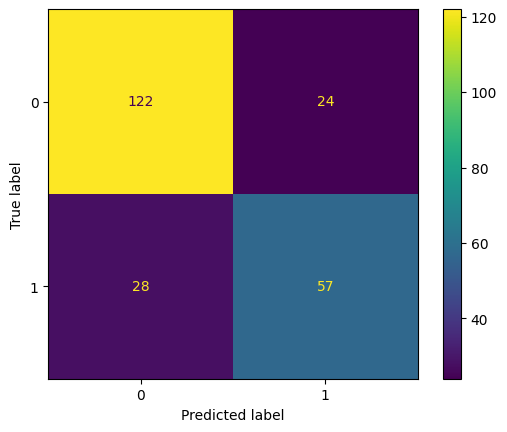

In [ ]:
# Matriz de Confusao
matriz_confusao = confusion_matrix(pred, y_teste)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao,
                              display_labels=clf.classes_)
disp.plot()
# Aqui, vemos uma superioridade inicial absurda para a classificacao de verdadeiros positivos, apesar de um pouco menor em verdadeiros negativos

In [ ]:
# Parametros
# n_estimators
for n_estimators in range(10, 500, 10):
  clf = xgb.XGBClassifier(seed=101,
                          n_estimators=n_estimators)

  clf.fit(x_treino, y_treino)
  pred = clf.predict(x_teste)
  acc = accuracy_score(pred, y_teste)

  if acc > 0.78:
    print('n_estimators =', n_estimators)
    print('Acuracia =', acc)
    print('='*100)
  # Novamente, 10 estimadores mostrou-se ser o melhor numero de estimadores

n_estimators = 10
Acuracia = 0.7835497835497836


In [ ]:
# max depth
for max_depth in range(2, 20):
  clf = xgb.XGBClassifier(seed=101,
                          n_estimators=10,
                          max_depth=max_depth)
  clf.fit(x_treino, y_treino)
  pred = clf.predict(x_teste)
  acc = accuracy_score(pred, y_teste)

  if acc > 0.78:
    print('max_depth =', max_depth)
    print('Acuracia =', acc)
    print('='*100)
  # A melhor max_depth ate agora e 4

max_depth = 4
Acuracia = 0.7878787878787878
max_depth = 6
Acuracia = 0.7835497835497836


In [ ]:
# Parametro de regularizacao
# Gamma (valor minimo de reducao de perda necessaria para nova divisao, controla a complexidade do modelo)
for gamma in np.arange(0, 1, 0.01):
  clf = xgb.XGBClassifier(seed=101,
                          n_estimators= 10,
                          max_depth=4,
                          gamma=gamma)

  clf.fit(x_treino, y_treino)
  pred = clf.predict(x_teste)
  acc = accuracy_score(pred, y_teste)

  if acc > 0.78:
    print('Gamma =', gamma)
    print('Acuracia =', acc)
    print('='*100)
  # Nao houve mudanca

Gamma = 0.0
Acuracia = 0.7878787878787878
Gamma = 0.8200000000000001
Acuracia = 0.7878787878787878
Gamma = 0.8300000000000001
Acuracia = 0.7835497835497836
Gamma = 0.84
Acuracia = 0.7835497835497836
Gamma = 0.85
Acuracia = 0.7835497835497836
Gamma = 0.86
Acuracia = 0.7835497835497836


In [ ]:
# Lambda (parametro de regularizacao L2, para os pesos das folhas da arvore)
for reg_lambda in np.arange(0, 1, 0.01):
  clf = xgb.XGBClassifier(seed=101,
                          n_estimators= 10,
                          max_depth=4,
                          reg_lambda=reg_lambda)

  clf.fit(x_treino, y_treino)
  pred = clf.predict(x_teste)
  acc = accuracy_score(pred, y_teste)

  if acc > 0.80:
    print('Lambda =', reg_lambda)
    print('Acuracia =', acc)
    print('='*100)
  # Lambda com valor de 0.58 teve um excelente incremento, aumentando a acuracia do modelo para 80%

Lambda = 0.58
Acuracia = 0.8008658008658008
Lambda = 0.59
Acuracia = 0.8008658008658008
Lambda = 0.6
Acuracia = 0.8008658008658008
Lambda = 0.61
Acuracia = 0.8008658008658008
Lambda = 0.62
Acuracia = 0.8008658008658008


In [ ]:
# Treinamento de modelo XGBoost definitivo
clf = xgb.XGBClassifier(seed= 101,
                        n_estimators=10,
                        max_depth=4,
                        reg_lambda=0.58)
clf.fit(x_treino, y_treino)
pred = clf.predict(x_teste)
acc = accuracy_score(pred, y_teste)

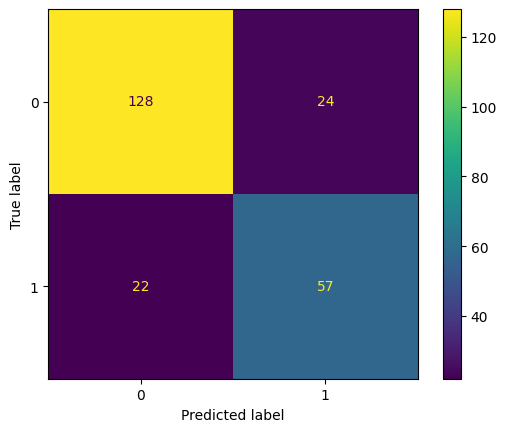

In [ ]:
# Matriz confusao do modelo
matriz_confusao = confusion_matrix(pred, y_teste)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao,
                              display_labels=clf.classes_)
disp.plot()

# Aumentou o numero de verdadeiros negativos e manteve 57 o de verdadeiros positivos.
# Ate o momento para classificacoes desses dados, o XGBoost foi o melhor modelo.